<a href="https://colab.research.google.com/github/martynalacha/Computational-Intelligence-Labs/blob/main/FuzzyLogic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Fuzzy Logic


In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 3.9 MB/s eta 0:00:00


The following code implements a Mamdani-type fuzzy inference system to regulate daily water output using temperature and humidity as input variables. Triangular membership functions are applied across all variables to enforce a partition of unity, which provides proportional and linear transitions on the control surface. The final crisp control signal is calculated using Center of Gravity (Centroid) defuzzification.

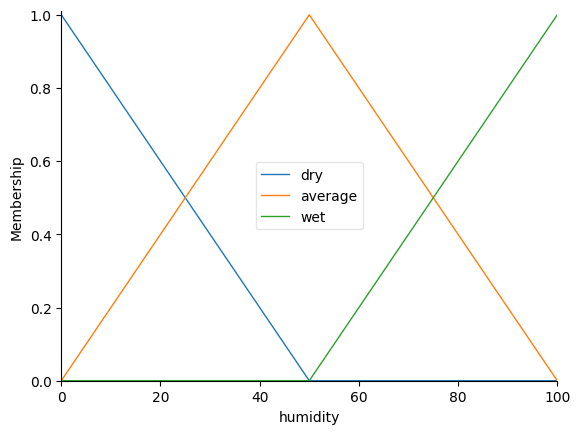

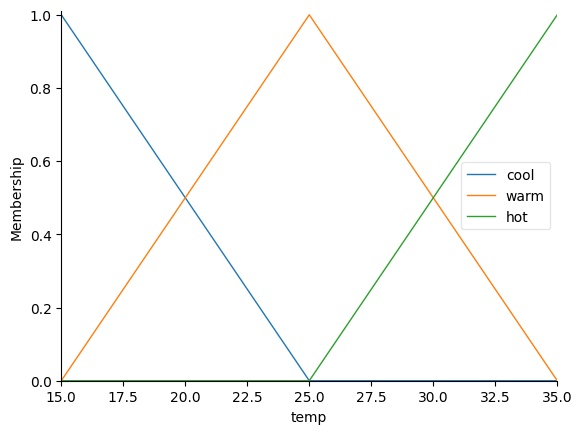

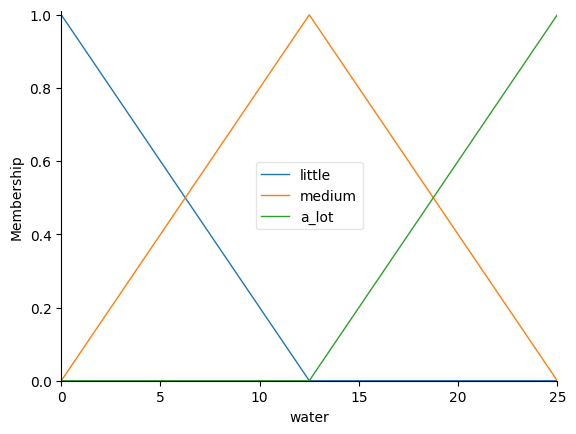

In [ ]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt
from skfuzzy import control as ctrl

humidity = ctrl.Antecedent(np.arange(0, 101, 1),'humidity')

temp = ctrl.Antecedent(np.arange(15, 35.1, 0.1),'temp')

water  = ctrl.Consequent(np.arange(0, 25.1, 0.1),'water')

# Humidity
humidity['dry'] = fuzz.trimf(humidity.universe, [0, 0, 50])
humidity['average'] = fuzz.trimf(humidity.universe, [0, 50, 100])
humidity['wet'] = fuzz.trimf(humidity.universe, [50, 100, 100])

# Temperature
temp['cool'] = fuzz.trimf(temp.universe, [15, 15, 25])
temp['warm'] = fuzz.trimf(temp.universe, [15, 25, 35])
temp['hot'] = fuzz.trimf(temp.universe, [25, 35, 35])

# Water
water['little'] = fuzz.trimf(water.universe, [0, 0, 12.5])
water['medium'] = fuzz.trimf(water.universe, [0, 12.5, 25])
water['a_lot'] = fuzz.trimf(water.universe, [12.5, 25, 25])

humidity.view()
temp.view()
water.view()

In [ ]:
# Define fuzzy rules mapped from the decision table
rule1 = ctrl.Rule(humidity['dry'] & temp['cool'], water['medium'])
rule2 = ctrl.Rule(humidity['average'] & temp['cool'], water['medium'])
rule3 = ctrl.Rule(humidity['wet'] & temp['cool'], water['little'])
rule4 = ctrl.Rule(humidity['dry'] & temp['warm'], water['a_lot'])
rule5 = ctrl.Rule(humidity['average'] & temp['warm'], water['medium'])
rule6 = ctrl.Rule(humidity['wet'] & temp['warm'], water['little'])
rule7 = ctrl.Rule(humidity['dry'] & temp['hot'], water['a_lot'])
rule8 = ctrl.Rule(humidity['average'] & temp['hot'], water['a_lot'])
rule9 = ctrl.Rule(humidity['wet'] & temp['hot'], water['medium'])

# Initialize the control system and simulation
control_system = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
model = ctrl.ControlSystemSimulation(control_system)

Model proponuje ilosc wody:  10.3


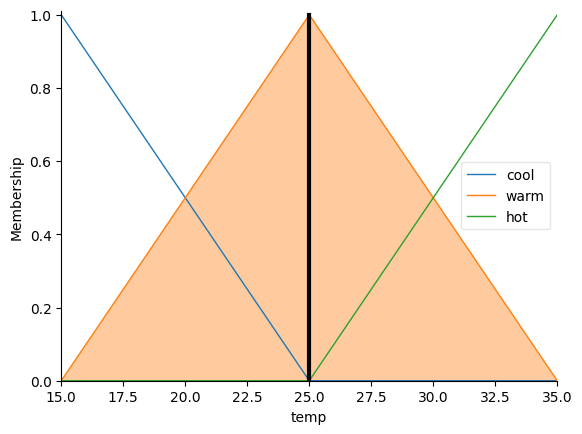

In [ ]:
# Calculate defuzzified output for specific crisp inputs
model.input['humidity'] = 80
model.input['temp'] = 25

model.compute()

print('Model proponuje ilosc wody: ', round(model.output['water'], 1))
temp.view(sim=model)

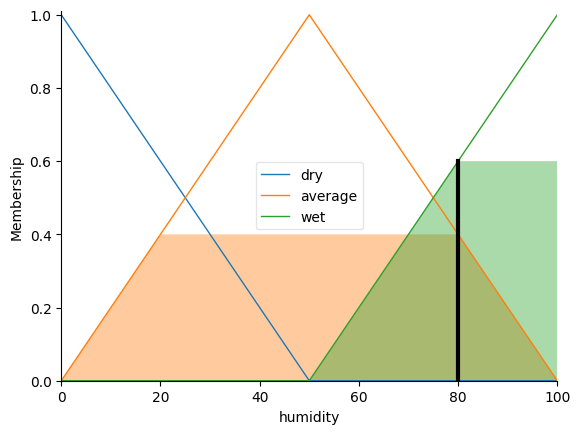

In [ ]:
humidity.view(sim=model)

<Axes: xlabel='humidity', ylabel='temp'>

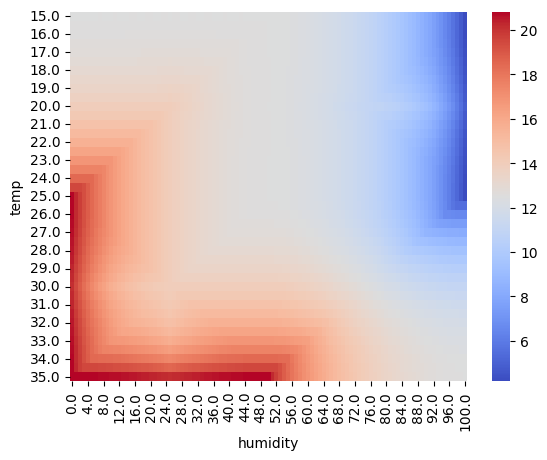

In [ ]:
# Generate grid for control surface evaluation
humidity_grid, temp_grid = np.meshgrid(np.arange(0, 101, 1), np.arange(15, 35.1, 0.5))

test_points = np.transpose(np.vstack((np.ravel(humidity_grid), np.ravel(temp_grid))))

# Preallocate numpy array for results
output_water = np.zeros(test_points.shape[0])

# Iterate through each point sequentially
for i in range(test_points.shape[0]):
    model.input['humidity'] = test_points[i, 0]
    model.input['temp'] = test_points[i, 1]
    model.compute()
    output_water[i] = model.output['water']

# Concatenate results
test_points = np.concatenate((test_points, output_water.reshape(-1, 1)), axis=1)

# Generate heatmap DataFrame
heatmap_df = pd.DataFrame(test_points, columns=['humidity', 'temp', 'water'])
pivot_table = heatmap_df.pivot(index='temp', columns='humidity', values='water')

sns.heatmap(pivot_table, cmap='coolwarm')

The following code implements a three-input Mamdani fuzzy logic system that adjusts alarm volume using sleep deficit, class importance, and snooze count as input variables. Gaussian membership functions are defined for all variables to represent continuous biological and behavioral metrics. This configuration generates a smooth, non-linear control surface and prevents dead zones during the rule aggregation and defuzzification processes.

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Define the universe of discourse
sleep_deficit = ctrl.Antecedent(np.arange(0, 12.1, 0.1), 'sleep_deficit')
class_importance = ctrl.Antecedent(np.arange(0, 101, 1), 'class_importance')
snooze_count = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'snooze_count')
alarm_volume = ctrl.Consequent(np.arange(60, 121, 1), 'alarm_volume')

# Define Gaussian membership functions for Sleep Deficit
sleep_deficit['low'] = fuzz.gaussmf(sleep_deficit.universe, 0, 2)
sleep_deficit['medium'] = fuzz.gaussmf(sleep_deficit.universe, 6, 2)
sleep_deficit['high'] = fuzz.gaussmf(sleep_deficit.universe, 12, 2)

# Define Gaussian membership functions for Class Importance
class_importance['optional'] = fuzz.gaussmf(class_importance.universe, 0, 20)
class_importance['recommended'] = fuzz.gaussmf(class_importance.universe, 50, 20)
class_importance['mandatory'] = fuzz.gaussmf(class_importance.universe, 100, 20)

# Define Gaussian membership functions for Snooze Count
snooze_count['none'] = fuzz.gaussmf(snooze_count.universe, 0, 1.5)
snooze_count['few'] = fuzz.gaussmf(snooze_count.universe, 4, 1.5)
snooze_count['many'] = fuzz.gaussmf(snooze_count.universe, 10, 1.5)

# Define Gaussian membership functions for Alarm Volume
alarm_volume['gentle'] = fuzz.gaussmf(alarm_volume.universe, 60, 10)
alarm_volume['loud'] = fuzz.gaussmf(alarm_volume.universe, 90, 10)
alarm_volume['deafening'] = fuzz.gaussmf(alarm_volume.universe, 120, 10)


Text(0.5, 1.0, 'Membership Functions: Sleep Deficit')

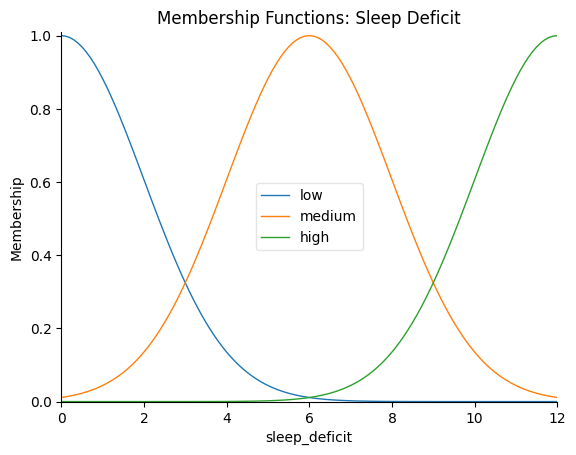

In [ ]:
sleep_deficit.view()
plt.title('Membership Functions: Sleep Deficit')


Text(0.5, 1.0, 'Membership Functions: Class Importance')

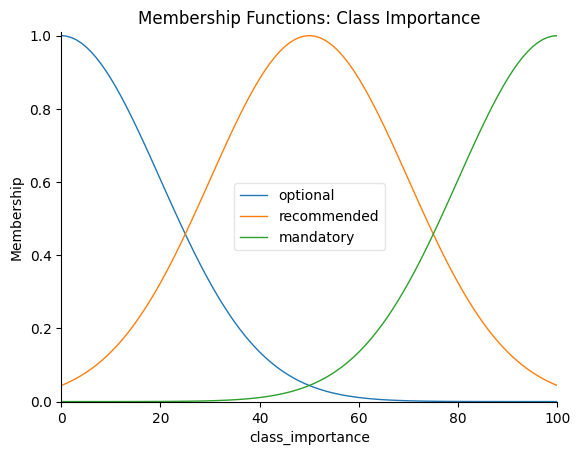

In [ ]:
class_importance.view()
plt.title('Membership Functions: Class Importance')


Text(0.5, 1.0, 'Membership Functions: Snooze Count')

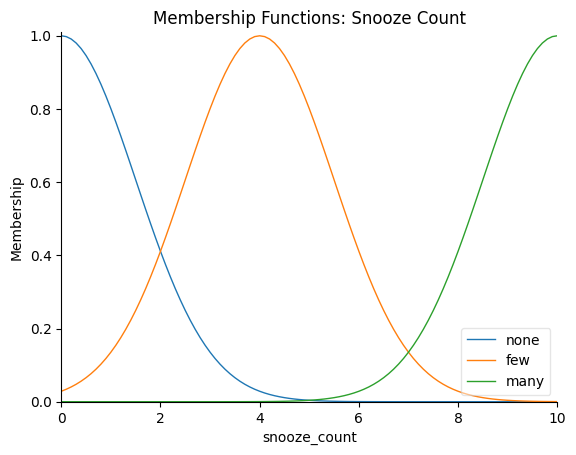

In [ ]:
snooze_count.view()
plt.title('Membership Functions: Snooze Count')


Text(0.5, 1.0, 'Membership Functions: Alarm Volume')

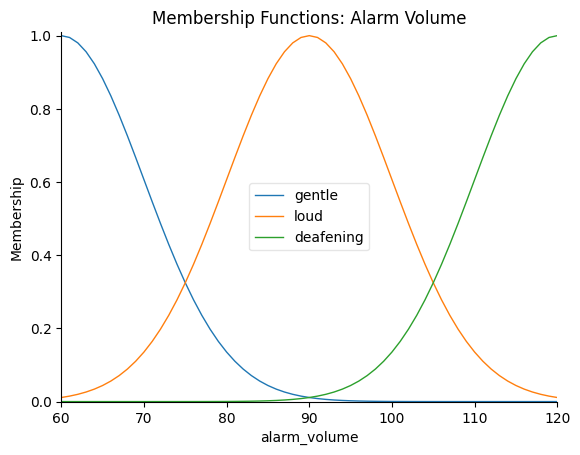

In [ ]:
alarm_volume.view()
plt.title('Membership Functions: Alarm Volume')

Calculated alarm volume (dB):  90.06


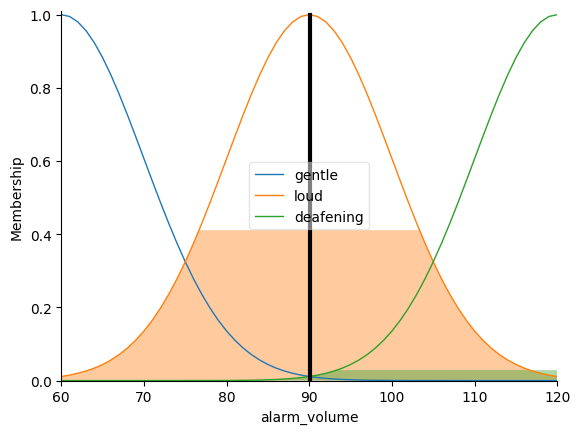

In [ ]:

# Define the fuzzy logic rules
rule1 = ctrl.Rule(class_importance['mandatory'] & sleep_deficit['high'] & snooze_count['many'], alarm_volume['deafening'])
rule2 = ctrl.Rule(class_importance['optional'] & sleep_deficit['high'], alarm_volume['gentle'])
rule3 = ctrl.Rule(snooze_count['none'] & sleep_deficit['low'], alarm_volume['gentle'])
rule4 = ctrl.Rule(class_importance['mandatory'] & snooze_count['few'], alarm_volume['loud'])
rule5 = ctrl.Rule(class_importance['recommended'] & sleep_deficit['medium'] & snooze_count['many'], alarm_volume['loud'])

# Build and configure the control system
alarm_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5])
alarm_sim = ctrl.ControlSystemSimulation(alarm_ctrl)

# Calculate output for specific input values
alarm_sim.input['sleep_deficit'] = 8.5
alarm_sim.input['class_importance'] = 80
alarm_sim.input['snooze_count'] = 6

# Execute the fuzzy inference mechanism
alarm_sim.compute()

# Print the resulting crisp output
print('Calculated alarm volume (dB): ', round(alarm_sim.output['alarm_volume'], 2))

# Visualize the final output distribution
alarm_volume.view(sim=alarm_sim)

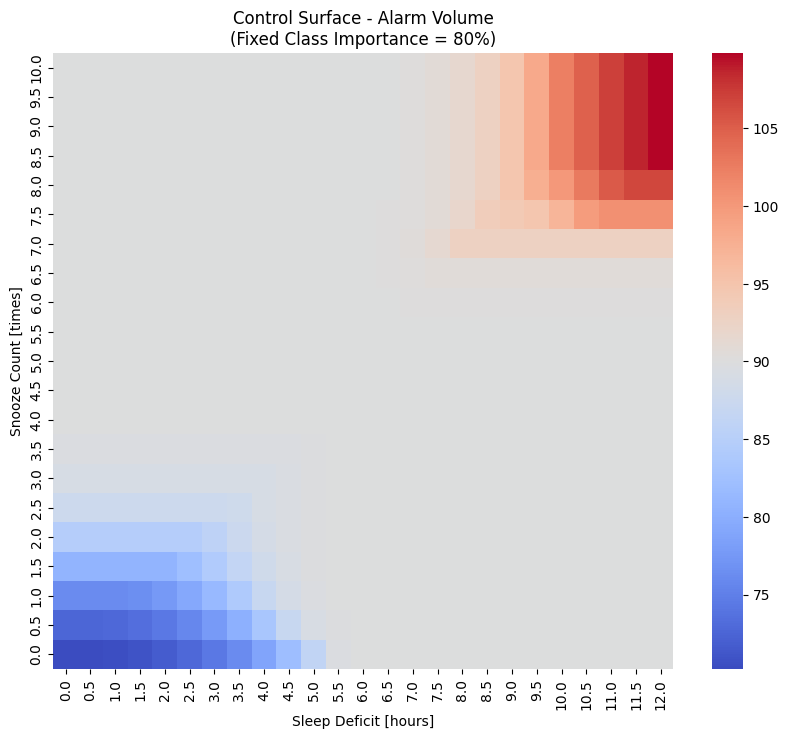

In [ ]:
# Fix class importance at 80% to project 3D input space onto a 2D heatmap
FIXED_CLASS_IMPORTANCE = 80

# Generate grid for the remaining two inputs
sleep_grid, snooze_grid = np.meshgrid(np.arange(0, 12.1, 0.5), np.arange(0, 10.1, 0.5))
test_points = np.transpose(np.vstack((np.ravel(sleep_grid), np.ravel(snooze_grid))))

# Preallocate array for results
volume_output = np.zeros(test_points.shape[0])

# Evaluate the system sequentially
for i in range(test_points.shape[0]):
    alarm_sim.input['sleep_deficit'] = test_points[i, 0]
    alarm_sim.input['snooze_count'] = test_points[i, 1]
    alarm_sim.input['class_importance'] = FIXED_CLASS_IMPORTANCE
    alarm_sim.compute()
    volume_output[i] = alarm_sim.output['alarm_volume']

# Merge and format data for seaborn
test_points = np.concatenate((test_points, volume_output.reshape(-1, 1)), axis=1)
heatmap_df = pd.DataFrame(test_points, columns=['sleep_deficit', 'snooze_count', 'alarm_volume'])
pivot_table = heatmap_df.pivot(index='snooze_count', columns='sleep_deficit', values='alarm_volume')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, cmap='coolwarm')
plt.gca().invert_yaxis()
plt.title(f'Control Surface - Alarm Volume\n(Fixed Class Importance = {FIXED_CLASS_IMPORTANCE}%)')
plt.xlabel('Sleep Deficit [hours]')
plt.ylabel('Snooze Count [times]')
plt.show()